<a href="https://colab.research.google.com/github/batireeduienkh6-source/2026_tues_bigdatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC---%EA%B3%BC%EC%A0%9C_20250068.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  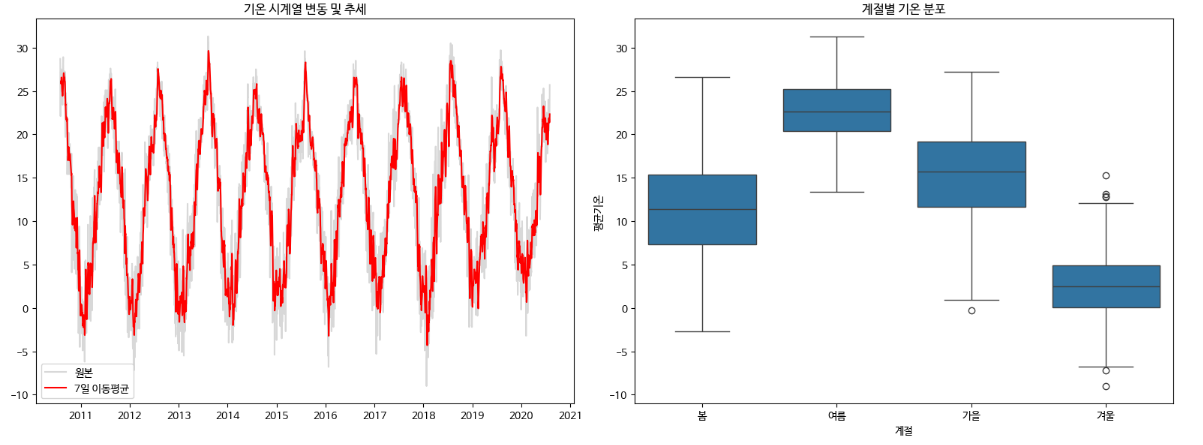

  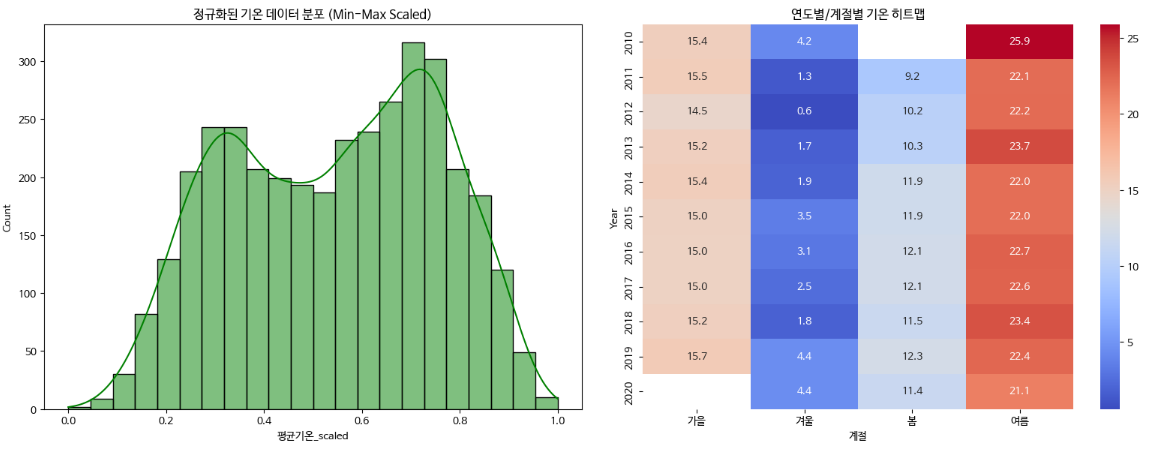



In [7]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# Delete font cache
if os.path.exists(os.path.expanduser('~/.cache/matplotlib')): # Check if cache exists before trying to remove it
    fm._load_fontmanager(try_read_cache=False)
    for f in os.listdir(os.path.expanduser('~/.cache/matplotlib')):
        os.remove(os.path.join(os.path.expanduser('~/.cache/matplotlib'), f))
fm._load_fontmanager(try_read_cache=False)

# Add font to font manager
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')

# Set font properties
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

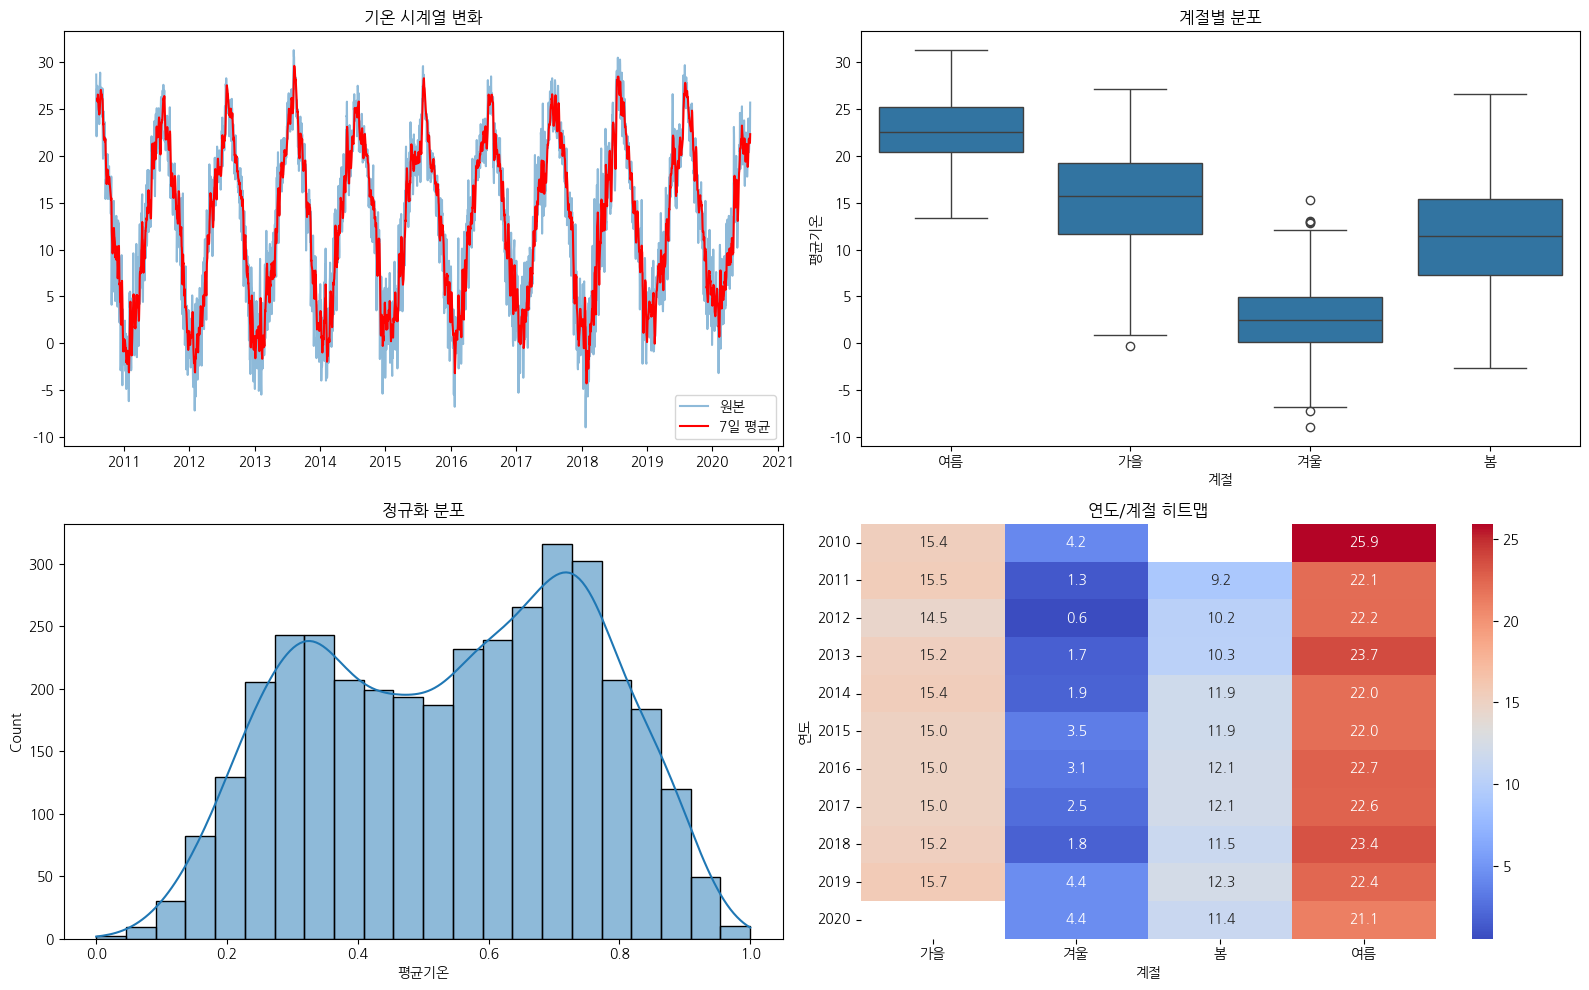

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. 데이터 로드
# ===============================
def load_data(url):
    return pd.read_csv(url, encoding='cp949')

# ===============================
# 2. 전처리
# ===============================
def preprocess(df):
    df['일시'] = pd.to_datetime(df['일시'])
    df.set_index('일시', inplace=True)

    def season(m):
        if m in [3,4,5]: return '봄'
        elif m in [6,7,8]: return '여름'
        elif m in [9,10,11]: return '가을'
        else: return '겨울'

    df['계절'] = df.index.month.map(season)
    return df

# ===============================
# 3. Min-Max Scaling
# ===============================
def min_max_scaling(series):
    return (series - series.min()) / (series.max() - series.min())

# ===============================
# 4. 시계열 처리
# ===============================
def add_moving_avg(df):
    df['7일 이동평균'] = df['평균기온'].rolling(7).mean()
    return df

# ===============================
# 5. 통계 및 Pivot
# ===============================
def create_stats(df):
    df['연도'] = df.index.year

    season_stats = df.groupby('계절')['평균기온'].describe()

    pivot = df.pivot_table(
        values='평균기온',
        index='연도',
        columns='계절',
        aggfunc='mean'
    )

    return season_stats, pivot

# ===============================
# 6. Excel 저장
# ===============================
def save_excel(df, season_stats, pivot):
    with pd.ExcelWriter('weather_analysis_report.xlsx') as writer:
        df.to_excel(writer, sheet_name='전처리 데이터')
        season_stats.to_excel(writer, sheet_name='계절별 통계')
        pivot.to_excel(writer, sheet_name='연도별 피벗')

# ===============================
# 7. 그래프
# ===============================
def plot_graphs(df, pivot):
    scaled = min_max_scaling(df['평균기온'].dropna())

    plt.figure(figsize=(16,10))

    # 시계열
    plt.subplot(2,2,1)
    plt.plot(df['평균기온'], alpha=0.5)
    plt.plot(df['7일 이동평균'], color='red')
    plt.title('기온 시계열 변화')
    plt.legend(['원본', '7일 평균'])

    # boxplot
    plt.subplot(2,2,2)
    sns.boxplot(x='계절', y='평균기온', data=df)
    plt.title('계절별 분포')

    # histogram
    plt.subplot(2,2,3)
    sns.histplot(scaled, kde=True)
    plt.title('정규화 분포')

    # heatmap
    plt.subplot(2,2,4)
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap='coolwarm')
    plt.title('연도/계절 히트맵')

    plt.tight_layout()
    plt.show()

# ===============================
# 8. MAIN
# ===============================
def main():
    url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"

    df = load_data(url)
    df = preprocess(df)
    df = add_moving_avg(df)

    season_stats, pivot = create_stats(df)

    save_excel(df, season_stats, pivot)

    plot_graphs(df, pivot)
    # ===============================
# 실행
# ===============================
main()